# 08 — Xuất hiện vật

**Mục tiêu.** Bảy notebook trước đã chọn xong mô hình (`xgboost` + `class_weight`, cấu hình mặc
định), ngưỡng (τ\* chọn trên out-of-fold) và cách giải thích (SHAP). Notebook này đóng gói các lựa
chọn đó thành **tệp**, để API nạp lúc khởi động mà không phải huấn luyện lại, không đọc
`creditcard.csv` (AR-01). Con số hiện trên màn hình demo phải là đúng con số trong báo cáo.

**Việc tương ứng:** T-35 … T-38 trong [TASKS.md](../TASKS.md).

| Việc | Sản phẩm | Điều kiện xong |
|---|---|---|
| T-35 | `models/model.joblib` — pipeline **hoàn chỉnh**, gồm cả scaler | nạp lại tệp, `predict_proba` cho đúng kết quả như trong notebook (AR-02) |
| T-36 | `models/explainer.joblib`, `models/metrics.json`, `models/threshold.json`, `models/oof_scores.npz` | cấu trúc khớp [06 §6](../docs/06-thiet-ke-luu-tru.md) |
| T-37 | `data/sample_pool.json` khoảng 200 giao dịch, bốn nhóm | mỗi nhóm "hard" có ít nhất 20 mẫu |
| T-38 | kiểm tra tái lập | PR-AUC lệch dưới 0,001 khi chạy lại trong kernel sạch (AC-M5, NFR-07) |

**Ba nguyên tắc chi phối notebook này** ([03 §2](../docs/03-thiet-ke-kien-truc.md)):

- **AR-01** — đây là nơi **duy nhất** ghi vào `models/`. API chỉ đọc.
- **AR-02** — `model.joblib` chứa cả bước chuẩn hoá `Amount` lẫn bộ phân loại. Tầng phục vụ chỉ còn
  gọi `build_features()` (dùng chung trong `src/`) rồi `predict_proba`.
- **AR-03** — ngưỡng nằm ở `threshold.json`, **không** nằm trong mô hình. Mô hình luôn trả xác suất.

**Không có con số mới nào ở đây.** Mọi chỉ số đã được tính và bàn ở notebook 05–07. Việc của
notebook này là tái tạo chúng từ đầu, đối chiếu với các bảng trong `reports/` mà những notebook đó
đã ghi, rồi mới xuất. Lệch ở đâu là dừng ở đó.

**Cách chạy.** Kernel sạch, `Run All`. Khoảng 5–10 phút tùy tải máy (12 lõi): điểm out-of-fold
1,5–4 phút, bootstrap 1,5–2 phút, SHAP trên toàn tập kiểm thử 30–50 giây.

In [1]:
import json
import subprocess
import sys
import tempfile
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import average_precision_score

from src import artifacts, plots
from src.config import (
    DATASET_DAYS,
    DEFAULT_COST_FN,
    DEFAULT_COST_FP,
    EXPLAINER_PATH,
    METRICS_PATH,
    MODEL_PATH,
    RANDOM_STATE,
    REPORTS_DIR,
    SAMPLE_POOL_PATH,
    TARGET,
    TEST_SET_PATH,
    THRESHOLD_PATH,
)
from src.data import load_prepared, split_data
from src.evaluate import baseline_pr_auc, curve_points, headline_metrics
from src.features import FEATURE_ORDER, RAW_REQUIRED_COLUMNS, build_features
from src.modeling import build_pipeline, make_cv, oof_scores
from src.threshold import NAIVE_THRESHOLD, compare_thresholds, confusion_counts, threshold_alternatives

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

# ---- Cấu hình -------------------------------------------------------------
# Tăng hậu tố khi đổi cấu hình hay dữ liệu huấn luyện. Chuỗi này đi vào mọi phản hồi của API
# và mọi dòng của bảng transactions (NFR-11), nên hai mô hình khác nhau không được trùng tên.
PHIEN_BAN = "xgb_scaleposweight_v1"
MO_HINH, CHIEN_LUOC = "xgboost", "class_weight"      # chốt ở T-24/T-25: cấu hình mặc định
N_BOOT = 1000
RECALL_TOI_THIEU = 0.90                                # 04 §6.3
NGAN_SACH_CANH_BAO = 200.0                             # cảnh báo mỗi ngày, 04 §6.3
THOI_DIEM = artifacts.utc_timestamp()

doi_chieu = []                                          # bảng đối chiếu cho T-38, điền dần
print(f"model_version = {PHIEN_BAN}   trained_at = {THOI_DIEM}")
print(f"shap {shap.__version__}, joblib {joblib.__version__}")

model_version = xgb_scaleposweight_v1   trained_at = 2026-09-28T08:01:09Z
shap 0.52.0, joblib 1.6.0


---
## 1. Dữ liệu và mô hình cuối cùng

Cách chia lặp lại đúng notebook 03–07 (`random_state=42`, 95 gian lận trong tập kiểm thử). Có
**hai thứ tự** của cùng một tập kiểm thử, và notebook giữ cả hai có chủ đích:

| Thứ tự | Biến | Dùng cho |
|---|---|---|
| của `split_data()` | `X_test`, `y_test`, `diem_test` | mọi chỉ số và khoảng tin cậy. Bootstrap phụ thuộc thứ tự dòng, nên phải giữ đúng thứ tự của notebook 05–07 thì khoảng tin cậy trong `metrics.json` mới trùng từng chữ số với báo cáo |
| của `data/test_set.parquet` (theo `Time`) | `tap_test`, `y_tep`, `diem_tep` | `test_scores`, cột `risk_score` và thư viện mẫu — những thứ API đọc lại theo dòng của tệp |

**Điểm out-of-fold được tính lại, không đọc từ `grid_results.npz`.** `threshold.json` phải xuất
phát từ đúng cấu hình đang xuất, không từ một tệp đệm có thể đã cũ. Tệp của giai đoạn 3 chỉ dùng
để đối chiếu.

In [2]:
df, bao_cao = load_prepared()
X_train_tho, X_test_tho, y_train, y_test = split_data(df, as_features=False)
X_train, X_test = build_features(X_train_tho), build_features(X_test_tho)
y_train, y_test = y_train.to_numpy(), y_test.to_numpy()
PHAN_TRAIN, PHAN_TEST = len(y_train) / len(df), len(y_test) / len(df)
assert int(y_test.sum()) == 95, "tập kiểm thử phải trùng với notebook 03 (95 gian lận)"

# data/test_set.parquet (notebook 03) phải chứa đúng các dòng của tập kiểm thử trên
tap_test = pd.read_parquet(TEST_SET_PATH).drop(columns=["risk_score"], errors="ignore")
COT = [*RAW_REQUIRED_COLUMNS, TARGET]

def theo_gia_tri(frame):
    return frame[COT].sort_values(COT).reset_index(drop=True)

pd.testing.assert_frame_equal(theo_gia_tri(tap_test), theo_gia_tri(X_test_tho.assign(**{TARGET: y_test})),
                              check_dtype=False, check_exact=True)
X_tep, y_tep = build_features(tap_test), tap_test[TARGET].to_numpy()
print(f"\n[x] test_set.parquet chứa đúng {len(tap_test):,} dòng / {int(y_tep.sum())} gian lận của tập kiểm thử")

bat_dau = time.perf_counter()
mo_hinh = build_pipeline(MO_HINH, CHIEN_LUOC, y=y_train).fit(X_train, y_train)
GIAY_HUAN_LUYEN = time.perf_counter() - bat_dau
diem_test = mo_hinh.predict_proba(X_test)[:, 1].astype("float64")
diem_tep = mo_hinh.predict_proba(X_tep)[:, 1].astype("float64")
assert np.array_equal(np.sort(diem_test), np.sort(diem_tep)), "hai thứ tự phải cho cùng tập điểm"

print(f"Huấn luyện trên {len(y_train):,} dòng: {GIAY_HUAN_LUYEN:.0f}s")
print(f"PR-AUC tập kiểm thử {average_precision_score(y_test, diem_test):.4f} "
      f"(đường cơ sở {baseline_pr_auc(y_test):.5f}); {np.unique(diem_test).size:,} điểm khác nhau")

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.



[x] test_set.parquet chứa đúng 56,746 dòng / 95 gian lận của tập kiểm thử


Huấn luyện trên 226,980 dòng: 51s
PR-AUC tập kiểm thử 0.8252 (đường cơ sở 0.00167); 56,204 điểm khác nhau


In [3]:
bat_dau = time.perf_counter()
oof = oof_scores(build_pipeline(MO_HINH, CHIEN_LUOC, y=y_train), X_train, y_train,
                 cv=make_cv(random_state=RANDOM_STATE))
print(f"Điểm out-of-fold tính lại: {time.perf_counter() - bat_dau:.0f}s, "
      f"PR-AUC {average_precision_score(y_train, oof):.4f}")

DUONG_DAN_NPZ = REPORTS_DIR / "grid_results.npz"
if DUONG_DAN_NPZ.exists():
    with np.load(DUONG_DAN_NPZ) as npz:
        oof_gd3 = npz[f"{MO_HINH}__{CHIEN_LUOC}"]
    lech = float(np.abs(oof - oof_gd3).max())
    doi_chieu.append({"đối chiếu": "điểm out-of-fold với giai đoạn 3 (grid_results.npz)",
                      "lệch lớn nhất": lech, "dung sai": 0.0})
    print(f"So với điểm lưu của giai đoạn 3: lệch tuyệt đối lớn nhất {lech:.1e}")
else:
    print("Không có reports/grid_results.npz — bỏ qua phần đối chiếu với giai đoạn 3")

Điểm out-of-fold tính lại: 69s, PR-AUC 0.8532
So với điểm lưu của giai đoạn 3: lệch tuyệt đối lớn nhất 0.0e+00


---
## 2. `model.joblib` — T-35

Tệp chứa **toàn bộ** pipeline đã fit trên 226.980 dòng của tập huấn luyện: `ColumnTransformer`
(`RobustScaler` cho `Amount`, học trung vị và IQR **chỉ** từ tập train) rồi `XGBClassifier`. Pipeline
nhận ma trận 31 cột của `build_features()`, đúng `FEATURE_ORDER`.

Điều kiện của T-35 được kiểm hai lần:

1. nạp lại ngay trong notebook;
2. nạp lại trong **một tiến trình Python mới**, không có biến nào của notebook, đọc `test_set.parquet`
   rồi đi qua `build_features()`. Đó chính là đường đi của API lúc khởi động. Nếu pipeline lỡ phụ
   thuộc vào trạng thái nào đó của notebook, lần thứ hai sẽ lộ ra.

In [4]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(mo_hinh, MODEL_PATH)
print(f"đã ghi {MODEL_PATH.relative_to(ROOT)} ({MODEL_PATH.stat().st_size / 1024**2:.2f} MB)")
print("các bước:", " → ".join(f"{ten} ({type(buoc).__name__})" for ten, buoc in mo_hinh.steps))
thang_do = mo_hinh.named_steps["preprocess"].named_transformers_["amount"]
print(f"RobustScaler của Amount, học trên tập train: trung vị {thang_do.center_[0]:.2f}, "
      f"IQR {thang_do.scale_[0]:.2f}")
assert list(mo_hinh.feature_names_in_) == FEATURE_ORDER

# (1) Nạp lại trong notebook
nap_lai = joblib.load(MODEL_PATH)
assert np.array_equal(nap_lai.predict_proba(X_test)[:, 1].astype("float64"), diem_test)

# (2) Nạp lại trong một tiến trình Python mới — giống API lúc khởi động
MA_KIEM = f'''
import sys, joblib, numpy as np, pandas as pd
sys.path.insert(0, r"{ROOT}")
from src.features import build_features
m = joblib.load(r"{MODEL_PATH}")
t = pd.read_parquet(r"{TEST_SET_PATH}").drop(columns=["risk_score"], errors="ignore")
np.save(sys.argv[1], m.predict_proba(build_features(t))[:, 1])
'''
with tempfile.TemporaryDirectory() as thu_muc:
    tep_diem = Path(thu_muc) / "diem.npy"
    bat_dau = time.perf_counter()
    subprocess.run([sys.executable, "-c", MA_KIEM, str(tep_diem)], check=True)
    giay_tien_trinh = time.perf_counter() - bat_dau
    diem_tien_trinh_moi = np.load(tep_diem).astype("float64")
assert np.array_equal(diem_tien_trinh_moi, diem_tep)

print("[x] nạp lại trong notebook: predict_proba trùng từng bit")
print(f"[x] nạp lại trong tiến trình Python mới ({giay_tien_trinh:.1f}s gồm cả khởi động Python): "
      f"trùng từng bit trên {len(diem_tep):,} giao dịch (AR-02)")

đã ghi models\model.joblib (1.17 MB)
các bước: preprocess (ColumnTransformer) → clf (XGBClassifier)
RobustScaler của Amount, học trên tập train: trung vị 22.08, IQR 72.16


[x] nạp lại trong notebook: predict_proba trùng từng bit
[x] nạp lại trong tiến trình Python mới (8.3s gồm cả khởi động Python): trùng từng bit trên 56,746 giao dịch (AR-02)


In [5]:
# 02 §8: test_set.parquet mang thêm điểm rủi ro của mô hình đã xuất. Notebook 03 để trống cột
# này; chế độ phát lại và màn hình hiệu năng đọc nó thay vì chấm lại cả tập mỗi lần khởi động.
tap_test.assign(risk_score=diem_tep).to_parquet(TEST_SET_PATH, index=False)

doc_lai = pd.read_parquet(TEST_SET_PATH)
assert list(doc_lai.columns) == [*COT, "risk_score"]
assert np.array_equal(doc_lai["risk_score"].to_numpy(), diem_tep)
assert doc_lai["Time"].is_monotonic_increasing
print(f"đã thêm cột risk_score vào {TEST_SET_PATH.relative_to(ROOT)} "
      f"({TEST_SET_PATH.stat().st_size / 1024**2:.2f} MB, {doc_lai.shape[1]} cột)")

đã thêm cột risk_score vào data\test_set.parquet (15.85 MB, 32 cột)


**Nhận xét T-35 — đạt.**

- `model.joblib` (1,2 MB) là pipeline hai bước: `ColumnTransformer` với `RobustScaler` cho `Amount`
  (trung vị 22,08, IQR 72,16, học **chỉ** trên tập train) rồi `XGBClassifier` 500 cây,
  `scale_pos_weight` 599,5. Scaler nằm trong tệp, nên tầng phục vụ không có chỗ nào để tự dựng lại
  bước chuẩn hoá và làm lệch nó (AR-02).
- Nạp lại trong notebook và trong một tiến trình Python mới đều cho `predict_proba` **trùng từng bit**
  trên 56.746 giao dịch. Tiến trình mới mất 7–15 giây tùy tải máy, gồm cả khởi động Python và import thư viện.
- PR-AUC 0,8252 trùng notebook 05. Điểm out-of-fold tính lại trùng **từng bit** với điểm lưu của
  giai đoạn 3 (lệch lớn nhất 0), nên τ\* ở `threshold.json` xuất phát đúng từ cấu hình đang xuất.
- `test_set.parquet` có thêm cột `risk_score` (32 cột, 15,9 MB), theo thứ tự `Time` như cũ.

---
## 3. `threshold.json`, `explainer.joblib`, `metrics.json` — T-36

### 3.1 `threshold.json`

τ\* và ba phương án còn lại được **chọn trên điểm out-of-fold** (ML-08), dò trên mọi điểm khác nhau
như notebook 06 đã chốt. Rồi so với `reports/threshold_comparison.csv` mà notebook 06 ghi ra trong
một phiên chạy khác: hai lần chọn phải ra đúng cùng các ngưỡng.

In [6]:
phuong_an = threshold_alternatives(
    y_train, oof, thresholds=np.unique(oof), cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP,
    min_recall=RECALL_TOI_THIEU, alert_budget=NGAN_SACH_CANH_BAO, sample_fraction=PHAN_TRAIN,
)
TAU_SAO = phuong_an["min_expected_cost"]

nguong_06 = pd.read_csv(REPORTS_DIR / "threshold_comparison.csv").set_index("name")["threshold"]
so_nguong = pd.DataFrame({"notebook 08": pd.Series(phuong_an), "notebook 06": nguong_06})
so_nguong["lệch"] = (so_nguong["notebook 08"] - so_nguong["notebook 06"]).abs()
display(so_nguong.style.format("{:.6g}"))
doi_chieu.append({"đối chiếu": "5 ngưỡng với notebook 06 (threshold_comparison.csv)",
                  "lệch lớn nhất": so_nguong["lệch"].max(), "dung sai": 1e-12})

nguong = artifacts.threshold_payload(
    default_threshold=TAU_SAO,
    alternatives=phuong_an,
    model_version=PHIEN_BAN,
    trained_at=THOI_DIEM,
    cost_fn=DEFAULT_COST_FN,
    cost_fp=DEFAULT_COST_FP,
    constraints={"min_recall": RECALL_TOI_THIEU, "alert_budget_per_day": NGAN_SACH_CANH_BAO},
)
assert artifacts.validate_threshold(nguong) == []
artifacts.write_json(THRESHOLD_PATH, nguong, indent=2)
print(f"\nđã ghi {THRESHOLD_PATH.relative_to(ROOT)}:")
print(THRESHOLD_PATH.read_text(encoding="utf-8"))

,notebook 08,notebook 06,lệch
budget_200_alerts,0.962479,0.962479,0
default_naive,0.5,0.5,0
max_f1,0.720512,0.720512,0
min_expected_cost,0.023173,0.023173,6.245e-17
recall_at_least_90,0.000536994,0.000536994,1.44199e-17



đã ghi models\threshold.json:
{
  "default_threshold": 0.023172983899712563,
  "selection_method": "min_expected_cost",
  "selected_on": "out_of_fold",
  "cost_false_negative": 122.21,
  "cost_false_positive": 5.0,
  "alternatives": {
    "min_expected_cost": 0.023172983899712563,
    "max_f1": 0.720512330532074,
    "recall_at_least_90": 0.0005369935533963144,
    "budget_200_alerts": 0.9624789953231812,
    "default_naive": 0.5
  },
  "model_version": "xgb_scaleposweight_v1",
  "trained_at": "2026-09-28T08:01:09Z",
  "constraints": {
    "min_recall": 0.9,
    "alert_budget_per_day": 200.0
  }
}


### 3.2 `explainer.joblib`

`shap.TreeExplainer` bọc bước `clf`, **không** bọc cả pipeline, nên đầu vào của nó là ma trận
**sau** tiền xử lý: `model[:-1].transform(build_features(x))`, trong đó `Amount` đã qua
`RobustScaler`. Đưa `X` thô vào thì SHAP của `Amount` sai mà không báo lỗi (bẫy đã ghi ở giai đoạn 5).

Kiểm tra trên **bản nạp lại** từ tệp, không trên đối tượng trong bộ nhớ:

- tính cộng: `base_value + Σ SHAP` bằng margin (logit) của booster trên toàn bộ 56.746 giao dịch;
- `mean|SHAP|` trùng với `reports/shap_ranking.csv` của notebook 07;
- thời gian giải thích **một** giao dịch — ngân sách của `/explain` là 50–200 ms (NFR-01).

In [7]:
tien_xu_ly, clf = mo_hinh[:-1], mo_hinh[-1]
joblib.dump(shap.TreeExplainer(clf), EXPLAINER_PATH)
giai_thich = joblib.load(EXPLAINER_PATH)                 # từ đây chỉ dùng bản đã nạp lại
print(f"đã ghi {EXPLAINER_PATH.relative_to(ROOT)} ({EXPLAINER_PATH.stat().st_size / 1024**2:.2f} MB)")

Z_test = tien_xu_ly.transform(X_test)
bat_dau = time.perf_counter()
sv = giai_thich.shap_values(Z_test)
GOC = float(np.ravel(giai_thich.expected_value)[0])
sai_so_cong = float(np.abs(GOC + sv.sum(axis=1) - clf.predict(Z_test, output_margin=True)).max())
print(f"SHAP cho {sv.shape[0]:,} × {sv.shape[1]}: {time.perf_counter() - bat_dau:.0f}s; "
      f"base value {GOC:.4f} (logit); |base + ΣSHAP − margin| lớn nhất {sai_so_cong:.1e}")
assert sai_so_cong < 1e-3
doi_chieu.append({"đối chiếu": "tính cộng của SHAP (base + ΣSHAP − margin)",
                  "lệch lớn nhất": sai_so_cong, "dung sai": 1e-3})

# Thời gian cho MỘT giao dịch, đo 50 lần — đây là đơn vị công việc của /explain
mot_dong = [Z_test.iloc[[i]] for i in range(50)]
thoi_gian = []
for z in mot_dong:
    bat_dau = time.perf_counter()
    giai_thich.shap_values(z)
    thoi_gian.append((time.perf_counter() - bat_dau) * 1000)
print(f"giải thích một giao dịch: trung vị {np.median(thoi_gian):.1f} ms, lớn nhất {max(thoi_gian):.1f} ms")

SV = pd.DataFrame(sv, columns=Z_test.columns)
xh_shap = pd.DataFrame({
    "mean_abs_shap": SV.abs().mean(),
    "mean_abs_shap_fraud": SV[y_test == 1].abs().mean(),
    "mean_shap_fraud": SV[y_test == 1].mean(),
}).sort_values("mean_abs_shap", ascending=False)
xh_07 = pd.read_csv(REPORTS_DIR / "shap_ranking.csv").set_index("feature")
lech_shap = float(((xh_shap["mean_abs_shap"] - xh_07["mean_abs_shap"]).abs() / xh_07["mean_abs_shap"]).max())
assert list(xh_shap.index) == list(xh_07.index), "thứ hạng mean|SHAP| khác notebook 07"
doi_chieu.append({"đối chiếu": "mean|SHAP| với notebook 07 (lệch tương đối)",
                  "lệch lớn nhất": lech_shap, "dung sai": 1e-4})
print(f"mean|SHAP|: cùng thứ hạng với notebook 07 cho cả 31 đặc trưng, lệch tương đối lớn nhất {lech_shap:.1e}")
print("5 đầu bảng:", ", ".join(f"{k} {v:.3f}" for k, v in xh_shap["mean_abs_shap"].head().items()))

đã ghi models\explainer.joblib (4.19 MB)


SHAP cho 56,746 × 31: 29s; base value 3.2763 (logit); |base + ΣSHAP − margin| lớn nhất 2.2e-05


giải thích một giao dịch: trung vị 13.4 ms, lớn nhất 20.1 ms
mean|SHAP|: cùng thứ hạng với notebook 07 cho cả 31 đặc trưng, lệch tương đối lớn nhất 4.0e-08
5 đầu bảng: V14 2.679, V4 1.878, V12 1.292, V11 1.002, V10 0.946


### 3.3 `metrics.json`

Mười hai khóa bắt buộc theo đúng thứ tự ở [06 §6.2](../docs/06-thiet-ke-luu-tru.md), rồi các mục bổ
sung mà màn hình UI-04 cần ([07 §6](../docs/07-thiet-ke-giao-dien.md)) nhưng khung ở 06 §6.2 chưa có:

| Khóa bổ sung | Nội dung | Phục vụ |
|---|---|---|
| `strategy_pr_curves` | đường PR out-of-fold của XGBoost dưới 5 chiến lược | UI-04 mục 2 |
| `baseline_comparison` | accuracy so với PR-AUC của mô hình rỗng, hồi quy logistic, cây quyết định và mô hình xuất | UI-04 mục 4, G-2 |
| `threshold_options` | 5 phương án ngưỡng đo trên tập kiểm thử | UI-03, bảng T-30 |
| `training` | tham số mô hình, thứ tự đặc trưng trước và sau tiền xử lý | API `/explain` đặt tên đặc trưng |
| `fingerprint` | dấu vân tay của điểm test và điểm out-of-fold | T-38 |
| `environment` | phiên bản Python, thư viện, số lõi | nạp `.joblib` trên máy khác |

`test_scores` theo thứ tự dòng của `test_set.parquet` và giữ **nguyên độ chính xác float64** —
UI-D1 so từng điểm với ngưỡng ngay trong trình duyệt, làm tròn là lệch TP/FP/FN ở sát ngưỡng (TC-12).

In [8]:
bat_dau = time.perf_counter()
chinh = artifacts.headline_block(headline_metrics(y_test, diem_test, TAU_SAO, n_boot=N_BOOT,
                                                  random_state=RANDOM_STATE))
print(f"bootstrap {N_BOOT} lần × 4 chỉ số: {time.perf_counter() - bat_dau:.0f}s")

# Đối chiếu với notebook 05 (final_test_metrics.csv, dòng "mặc định"): cùng mô hình, cùng thứ tự,
# cùng hạt giống bootstrap → phải trùng cả giá trị lẫn hai đầu khoảng tin cậy
bang_05 = pd.read_csv(REPORTS_DIR / "final_test_metrics.csv")
bang_05 = bang_05[bang_05["cấu hình"] == "mặc định"].set_index("chỉ số")
so_05 = pd.DataFrame({
    (chi_so, phan): {"notebook 08": chinh[chi_so][phan], "notebook 05": bang_05.loc[chi_so, cot]}
    for chi_so in artifacts.HEADLINE_CI_METRICS
    for phan, cot in (("value", "giá trị"), ("ci_low", "ci_low"), ("ci_high", "ci_high"))
}).T
so_05["lệch"] = (so_05["notebook 08"] - so_05["notebook 05"]).abs()
display(so_05.style.format("{:.6f}"))
doi_chieu.append({"đối chiếu": "chỉ số chính + KTC với notebook 05 (final_test_metrics.csv)",
                  "lệch lớn nhất": so_05["lệch"].max(), "dung sai": 1e-12})

tp, fp, fn, tn = confusion_counts(y_test, diem_test, TAU_SAO)
print(f"tại τ* = {TAU_SAO:.5f}: TP {tp}, FP {fp}, FN {fn}, TN {tn}")

bootstrap 1000 lần × 4 chỉ số: 94s


tại τ* = 0.02317: TP 77, FP 38, FN 18, TN 56613


In [9]:
# ---- các mục lấy từ bảng của notebook trước --------------------------------------------
def ban_ghi(frame, doi_ten=None):
    return artifacts.to_jsonable(frame.rename(columns=doi_ten or {}))

luoi = pd.read_csv(REPORTS_DIR / "grid_results.csv").sort_values("pr_auc_mean", ascending=False)
luoi = luoi.drop(columns=["che_do"], errors="ignore").rename(
    columns={"roc_auc_mean": "roc_auc", "total_seconds": "fit_seconds"})
assert len(luoi) == 20, "bảng lưới phải đủ 20 tổ hợp (AC-M3)"

chia = pd.read_csv(REPORTS_DIR / "split_comparison.csv").set_index("cách chia")
KHOA_CHIA = {"ngẫu nhiên 80/20": "random_stratified",
             "ngẫu nhiên, train thu nhỏ bằng ngày 1": "random_downsized_day1",
             "theo thời gian: ngày 1 → ngày 2": "temporal"}
TEN_COT_CHIA = {"train: dòng": "n_train", "train: gian lận": "n_fraud_train", "test: dòng": "n_test",
                "test: gian lận": "n_fraud_test", "PR-AUC OOF (train)": "pr_auc_oof", "PR-AUC": "pr_auc",
                "PR-AUC ci_low": "pr_auc_ci_low", "PR-AUC ci_high": "pr_auc_ci_high", "τ*": "threshold",
                "recall ci_low": "recall_ci_low", "recall ci_high": "recall_ci_high",
                "precision ci_low": "precision_ci_low", "precision ci_high": "precision_ci_high",
                "TP": "tp", "FP": "fp", "FN": "fn"}
DEM = ("n_train", "n_fraud_train", "n_test", "n_fraud_test", "tp", "fp", "fn")
cach_chia = {}
for ten, dong in chia.rename(columns=TEN_COT_CHIA).iterrows():
    # iterrows() gộp cả dòng về float64 — trả các cột đếm về số nguyên
    cach_chia[KHOA_CHIA[ten]] = {k: int(v) if k in DEM else float(v) for k, v in dong.items()}
assert set(cach_chia) == set(KHOA_CHIA.values())
doi_chieu.append({"đối chiếu": "PR-AUC với notebook 05 (split_comparison.csv, ngẫu nhiên 80/20)",
                  "lệch lớn nhất": abs(cach_chia["random_stratified"]["pr_auc"] - chinh["pr_auc"]["value"]),
                  "dung sai": 1e-12})

shap_toan_cuc = xh_shap.join(xh_07[["rank_cohens_d", "rank_cliffs_delta", "rank_pearson",
                                    "abs_cohens_d", "abs_cliffs_delta", "lr_std_coef", "rank_lr"]])
shap_toan_cuc["share"] = shap_toan_cuc["mean_abs_shap"] / shap_toan_cuc["mean_abs_shap"].sum()
shap_toan_cuc["rank_shap"] = np.arange(1, len(shap_toan_cuc) + 1)
shap_toan_cuc = shap_toan_cuc.rename_axis("feature").reset_index()

moc = pd.read_csv(REPORTS_DIR / "baseline_results.csv").rename(columns={
    "mô hình": "model", "PR-AUC": "pr_auc", "ROC-AUC": "roc_auc", "F1": "f1",
    "TP": "tp", "FP": "fp", "FN": "fn", "TN": "tn", "giây huấn luyện": "fit_seconds"})
moc = pd.concat([moc, pd.DataFrame([{
    "model": f"{MO_HINH} + {CHIEN_LUOC} (mô hình xuất)", "accuracy": (tp + tn) / len(y_test),
    "pr_auc": chinh["pr_auc"]["value"], "pr_auc_ci_low": chinh["pr_auc"]["ci_low"],
    "pr_auc_ci_high": chinh["pr_auc"]["ci_high"], "roc_auc": chinh["roc_auc"]["value"],
    "precision": chinh["precision"]["value"], "recall": chinh["recall"]["value"], "f1": chinh["f1"]["value"],
    "tp": tp, "fp": fp, "fn": fn, "tn": tn, "fit_seconds": GIAY_HUAN_LUYEN, "threshold": TAU_SAO,
    "n_test": len(y_test), "n_fraud_test": int(y_test.sum())}])], ignore_index=True)

phuong_an_test = compare_thresholds(y_test, diem_test, phuong_an, cost_fn=DEFAULT_COST_FN,
                                    cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TEST)
bang_06 = pd.read_csv(REPORTS_DIR / "threshold_comparison.csv").set_index("name")
lech_nguong = (phuong_an_test.set_index("name")[["tp", "fp", "fn", "expected_cost"]]
               - bang_06[["tp", "fp", "fn", "expected_cost"]]).abs().to_numpy().max()
doi_chieu.append({"đối chiếu": "TP/FP/FN/chi phí của 5 phương án với notebook 06",
                  "lệch lớn nhất": lech_nguong, "dung sai": 1e-9})

# Đường PR out-of-fold của 5 chiến lược cho XGBoost (hình T-21) — cần điểm lưu của giai đoạn 3
duong_chien_luoc = None
if DUONG_DAN_NPZ.exists():
    luoi_xgb = luoi[luoi["model"] == MO_HINH].set_index("strategy")
    with np.load(DUONG_DAN_NPZ) as npz:
        duong_chien_luoc = {
            "model": MO_HINH, "evaluated_on": "out_of_fold", "baseline": baseline_pr_auc(y_train),
            "curves": [{"strategy": s, "pr_auc_mean": luoi_xgb.loc[s, "pr_auc_mean"],
                        "pr_auc_std": luoi_xgb.loc[s, "pr_auc_std"],
                        **curve_points(y_train, npz[f"{MO_HINH}__{s}"], max_points=300)["pr_curve"]}
                       for s in luoi_xgb.index],
        }
print(f"lưới {len(luoi)} dòng, {len(cach_chia)} cách chia, {len(shap_toan_cuc)} đặc trưng SHAP, "
      f"{len(moc)} mô hình mốc, {len(phuong_an_test)} phương án ngưỡng, "
      f"{0 if duong_chien_luoc is None else len(duong_chien_luoc['curves'])} đường PR chiến lược")

lưới 20 dòng, 3 cách chia, 31 đặc trưng SHAP, 4 mô hình mốc, 5 phương án ngưỡng, 5 đường PR chiến lược


In [10]:
tham_so = clf.get_params()
noi_dung = artifacts.metrics_payload(
    model_version=PHIEN_BAN,
    trained_at=THOI_DIEM,
    dataset={
        "n_total": len(df),
        "n_duplicates_removed": bao_cao.n_duplicates,
        "n_train": len(y_train),
        "n_fraud_train": int(y_train.sum()),
        "n_test": len(y_tep),
        "n_fraud_test": int(y_tep.sum()),
        "positive_rate": float(y_tep.mean()),
        "test_fraction": PHAN_TEST,
        "days": DATASET_DAYS,
        "split": f"phân tầng 80/20 theo Class, random_state={RANDOM_STATE}, sau khi loại trùng lặp",
        "test_scores_order": "dòng của data/test_set.parquet (Time tăng dần)",
    },
    headline=chinh,
    confusion_at_default={"threshold": TAU_SAO, "tp": tp, "fp": fp, "fn": fn, "tn": tn},
    curves=curve_points(y_test, diem_test),
    cost_curve=artifacts.cost_curve_points(y_test, diem_test, cost_fn=DEFAULT_COST_FN,
                                           cost_fp=DEFAULT_COST_FP, sample_fraction=PHAN_TEST),
    y_true=y_tep,
    y_scores=diem_tep,
    grid_results=ban_ghi(luoi),
    shap_global=ban_ghi(shap_toan_cuc),
    split_comparison=cach_chia,
    strategy_pr_curves=duong_chien_luoc,
    baseline_comparison=ban_ghi(moc),
    threshold_options=ban_ghi(phuong_an_test),
    training={
        "model": MO_HINH,
        "strategy": CHIEN_LUOC,
        "params": {k: tham_so[k] for k in ("n_estimators", "learning_rate", "max_depth", "subsample",
                                          "colsample_bytree", "scale_pos_weight", "tree_method",
                                          "random_state")},
        "fit_seconds": GIAY_HUAN_LUYEN,
        "feature_order": FEATURE_ORDER,
        "model_feature_names": list(Z_test.columns),
        "shap_base_value": GOC,
        "shap_output": "log-odds",
    },
    fingerprint={"test_scores_sha256": artifacts.score_fingerprint(diem_tep),
                 "oof_scores_sha256": artifacts.score_fingerprint(oof)},
    environment=artifacts.environment_info(),
)
assert artifacts.validate_metrics(noi_dung) == []
artifacts.write_json(METRICS_PATH, noi_dung)
print(f"đã ghi {METRICS_PATH.relative_to(ROOT)} ({METRICS_PATH.stat().st_size / 1024**2:.2f} MB)")

kich_thuoc = pd.Series({k: len(json.dumps(artifacts.to_jsonable(v))) / 1024
                        for k, v in noi_dung.items()}).sort_values(ascending=False)
print("kích thước từng khóa (KB):", ", ".join(f"{k} {v:,.0f}" for k, v in kich_thuoc.head(6).items()))

đã ghi models\metrics.json (1.60 MB)


kích thước từng khóa (KB): test_scores 1,460, strategy_pr_curves 82, cost_curve 40, pr_curve 17, shap_global 12, grid_results 10


### 3.4 `oof_scores.npz`

`POST /threshold/optimize` (API-12) là một phép **chọn** ngưỡng, nên theo ML-08 nó phải chọn trên
điểm out-of-fold chứ không trên `test_scores`. Tệp này mang 226.980 điểm out-of-fold và nhãn của
tập huấn luyện sang API, giữ nguyên kiểu float32 của `predict_proba`: với chi phí mặc định, API
phải chọn ra **đúng** τ\* của `threshold.json`. Chỉ số tại ngưỡng đã chọn vẫn đo trên tập kiểm thử.

In [11]:
from src.config import OOF_SCORES_PATH

artifacts.write_oof_scores(OOF_SCORES_PATH, y_train, oof, train_fraction=PHAN_TRAIN, days=DATASET_DAYS)
oof_doc_lai = artifacts.read_oof_scores(OOF_SCORES_PATH)
assert artifacts.validate_oof_scores(oof_doc_lai, fingerprint=noi_dung["fingerprint"]["oof_scores_sha256"]) == []
assert oof_doc_lai["y_score"].dtype == oof.dtype and np.array_equal(oof_doc_lai["y_score"], oof)

# Chọn lại τ* từ tệp vừa ghi, đúng cách API-12 sẽ làm — phải ra đúng ngưỡng trong threshold.json
tau_tu_tep = threshold_alternatives(
    oof_doc_lai["y_true"], oof_doc_lai["y_score"], thresholds=np.unique(oof_doc_lai["y_score"]),
    cost_fn=DEFAULT_COST_FN, cost_fp=DEFAULT_COST_FP, min_recall=RECALL_TOI_THIEU,
    alert_budget=NGAN_SACH_CANH_BAO, sample_fraction=oof_doc_lai["train_fraction"],
)["min_expected_cost"]
assert tau_tu_tep == TAU_SAO
print(f"đã ghi {OOF_SCORES_PATH.relative_to(ROOT)} ({OOF_SCORES_PATH.stat().st_size / 1024**2:.2f} MB, "
      f"{oof_doc_lai['y_score'].size:,} điểm {oof_doc_lai['y_score'].dtype}); chọn lại từ tệp ra đúng τ* = {tau_tu_tep:.6f}")

đã ghi models\oof_scores.npz (0.80 MB, 226,980 điểm float32); chọn lại từ tệp ra đúng τ* = 0.023173


**Nhận xét T-36 — đạt, cả ba tệp đúng cấu trúc 06 §6 và trùng số với notebook 05–07.**

- **`threshold.json`**: τ\* = 0,023173, chọn trên out-of-fold. Năm ngưỡng trùng notebook 06 tới
  6·10⁻¹⁷, tức sai số biểu diễn số thực. Giá trị 0,0473 trong ví dụ ở 06 §6.1 chỉ là số giữ chỗ.
- **`explainer.joblib`** (4,2 MB, trong dự báo 1–5 MB của 06 §9): tính cộng khớp margin tới
  2,2·10⁻⁵ trên toàn tập kiểm thử, `mean|SHAP|` cùng thứ hạng với notebook 07 ở cả 31 đặc trưng.
  Giải thích **một** giao dịch mất trung vị 17–21 ms, chậm nhất 39–71 ms qua hai lần chạy, dưới ngân
  sách 50–200 ms của NFR-01. Ở `/explain`, phần tốn thời gian sẽ là HTTP và cơ sở dữ liệu, không phải SHAP.
- **`metrics.json`** (1,6 MB, dưới dự báo 3–8 MB của 06 §9): 90% dung lượng là `test_scores`. Chưa cần
  tách `test_scores` ra `.npz` như phương án dự phòng ở 06 §6.2. Chỉ số chính và **cả hai đầu**
  khoảng tin cậy trùng notebook 05 tới 10⁻¹⁶. Điều này có được vì bootstrap chạy trên đúng thứ tự
  dòng và hạt giống của notebook 05. Nhờ vậy màn hình UI-04 in đúng con số của báo cáo (AR-01).
- **Khác ví dụ ở 06 §6.2**, đã cập nhật lại tài liệu: `confusion_at_default` mang thêm `threshold`;
  `baseline_pr_auc` là số chứ không phải object; `n_fraud_test` là 95 (ví dụ ghi 98, con số trước khi
  loại trùng lặp); `split_comparison` có thêm dòng đối chứng `random_downsized_day1` của T-27; và
  sáu khóa bổ sung cho UI-04 ở bảng trên.

---
## 4. `data/sample_pool.json` — T-37

Thư viện mẫu cho buổi trình diễn: khoảng 50 gian lận và 150 hợp lệ, lấy từ **tập kiểm thử** chứ
không từ tập huấn luyện (điểm của một giao dịch mô hình đã học thuộc thì đẹp một cách giả tạo).

| Nhóm | Luật | Vì sao |
|---|---|---|
| `fraud_easy` | gian lận, điểm ≥ 0,5 | mô hình bắt chắc chắn |
| `fraud_hard` | gian lận, điểm < 0,5 | ngưỡng mặc định bỏ lọt. Gồm cả vụ bị bỏ lọt ở τ\* lẫn vụ **chỉ** bắt được khi hạ ngưỡng về τ\* — nhóm sau làm cảnh kéo thanh trượt ở buổi bảo vệ có ý nghĩa |
| `legit_easy` | hợp lệ, điểm < τ\* | cho qua đúng |
| `legit_hard` | hợp lệ, điểm ≥ τ\* | cảnh báo giả ở chính sách đang chạy |

Hai nhóm "hard" dùng hai mốc khác nhau vì chúng khó theo hai nghĩa khác nhau: gian lận khó là vụ
mô hình **không tự tin**, hợp lệ khó là giao dịch **bị chặn nhầm**. Dùng τ\* cho cả hai thì
`fraud_hard` chỉ còn 18 vụ, không đạt điều kiện 20 của T-37.

Trong mỗi nhóm, mẫu được lấy **trải đều theo thứ hạng điểm**, không ngẫu nhiên: chạy lại cho đúng
cùng một thư viện, và mỗi nhóm phủ hết dải điểm của nó.

In [12]:
cac_mau = artifacts.select_sample_pool(tap_test, y_tep, diem_tep, reference_threshold=TAU_SAO,
                                       fraud_cutoff=NAIVE_THRESHOLD)
thu_vien = artifacts.sample_pool_payload(cac_mau, generated_at=THOI_DIEM, model_version=PHIEN_BAN,
                                         reference_threshold=TAU_SAO, fraud_cutoff=NAIVE_THRESHOLD)
assert artifacts.validate_sample_pool(thu_vien) == []

# Chấm lại 30 cột thô của từng mẫu bằng bản đã nạp lại — đúng đường đi của API-02
tho = pd.DataFrame([m["features"] for m in cac_mau])
cham_lai = nap_lai.predict_proba(build_features(tho))[:, 1].astype("float64")
assert np.array_equal(cham_lai, [m["risk_score"] for m in cac_mau])

artifacts.write_json(SAMPLE_POOL_PATH, thu_vien, indent=1)
print(f"đã ghi {SAMPLE_POOL_PATH.relative_to(ROOT)} ({SAMPLE_POOL_PATH.stat().st_size / 1024:.0f} KB), "
      f"{len(cac_mau)} mẫu; chấm lại từ 30 cột thô ra đúng risk_score đã lưu")

bang_mau = pd.DataFrame([{k: m[k] for k in ("id", "category", "label", "risk_score", "description")}
                         | {"Amount": m["features"]["Amount"]} for m in cac_mau])
tom_tat = bang_mau.groupby("category", sort=False).agg(
    so_mau=("id", "size"), diem_thap_nhat=("risk_score", "min"), diem_trung_vi=("risk_score", "median"),
    diem_cao_nhat=("risk_score", "max"), amount_trung_vi=("Amount", "median"))
display(tom_tat.style.format({"diem_thap_nhat": "{:.2e}", "diem_trung_vi": "{:.2e}",
                              "diem_cao_nhat": "{:.4f}", "amount_trung_vi": "{:.2f}"}))
print("Mô tả trong từng nhóm:")
display(bang_mau.groupby(["category", "description"], sort=False).size().rename("số mẫu").to_frame())

đã ghi data\sample_pool.json (219 KB), 200 mẫu; chấm lại từ 30 cột thô ra đúng risk_score đã lưu


,so_mau,diem_thap_nhat,diem_trung_vi,diem_cao_nhat,amount_trung_vi
category,,,,,
fraud_easy,29,5.86e-01,1.00e+00,1.0000,37.93
fraud_hard,21,1.87e-06,2.38e-04,0.2995,2.22
legit_easy,112,1.67e-08,2.67e-06,0.0227,21.38
legit_hard,38,2.40e-02,6.53e-02,1.0000,41.36


Mô tả trong từng nhóm:


số mẫu
category   description                                               
fraud_easy Gian lận điển hình — điểm rủi ro rất cao                27
           Gian lận — điểm rủi ro cao, vượt cả ngưỡng 0,5           2
fraud_hard Gian lận ở vùng biên — chỉ bắt được khi hạ ngưỡ...       3
           Gian lận bị bỏ lọt — điểm dưới cả ngưỡng đề xuấ...      18
legit_easy Hợp lệ sát ngưỡng — vẫn được cho qua ở τ*                1
           Hợp lệ điển hình — điểm rủi ro rất thấp                111
legit_hard Hợp lệ nhưng điểm rất cao — cảnh báo giả ngay c...       4
           Hợp lệ nhưng điểm cao — cảnh báo giả ở ngưỡng đ...      34

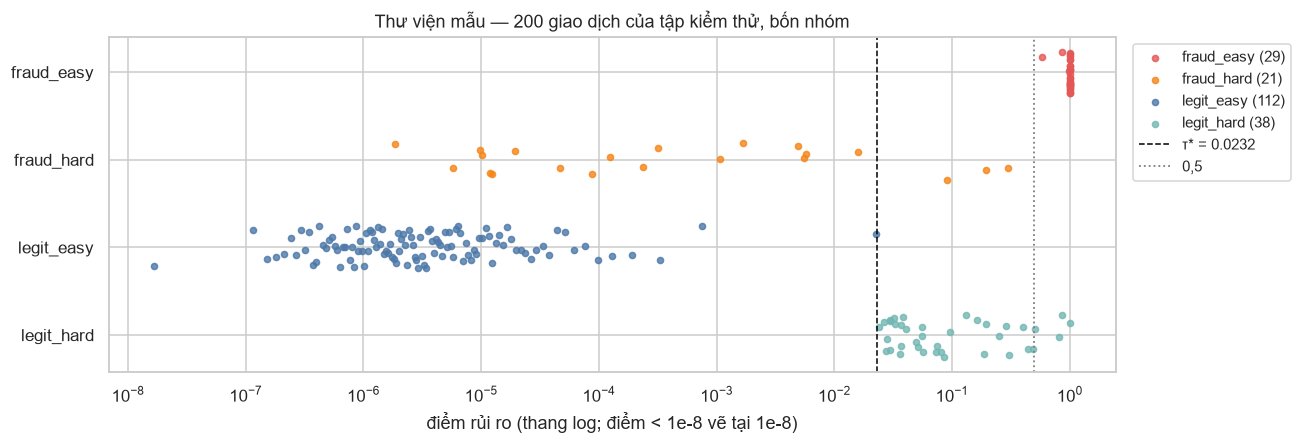

In [13]:
fig, ax = plt.subplots(figsize=(12, 4.2))
MAU_NHOM = {"fraud_easy": "#E45756", "fraud_hard": "#F58518", "legit_easy": "#4C78A8", "legit_hard": "#72B7B2"}
rng = np.random.default_rng(RANDOM_STATE)
for vi_tri, (nhom, mau) in enumerate(MAU_NHOM.items()):
    diem = bang_mau.loc[bang_mau["category"] == nhom, "risk_score"].clip(lower=1e-8)
    ax.scatter(diem, vi_tri + rng.uniform(-0.25, 0.25, len(diem)), s=16, color=mau, alpha=0.8,
               label=f"{nhom} ({len(diem)})")
ax.axvline(TAU_SAO, c="black", ls="--", lw=1, label=f"τ* = {TAU_SAO:.4f}")
ax.axvline(NAIVE_THRESHOLD, c="grey", ls=":", lw=1.2, label="0,5")
ax.set_xscale("log")
ax.set_yticks(range(4), list(MAU_NHOM))
ax.invert_yaxis()
ax.set_xlabel("điểm rủi ro (thang log; điểm < 1e-8 vẽ tại 1e-8)")
ax.set_title(f"Thư viện mẫu — {len(bang_mau)} giao dịch của tập kiểm thử, bốn nhóm")
ax.legend(fontsize="small", loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
plots.save_fig(fig, "08_sample_pool.png")
plt.show()

**Nhận xét T-37 — đạt: 200 mẫu, `fraud_hard` 21 và `legit_hard` 38, cả hai ≥ 20.**

| Nhóm | Số mẫu | Điểm | Là gì |
|---|---|---|---|
| `fraud_easy` | 29 | 0,59 – 1,00 | lấy trải đều từ 74 vụ gian lận có điểm ≥ 0,5 |
| `fraud_hard` | 21 | 1,9·10⁻⁶ – 0,30 | **toàn bộ** gian lận dưới 0,5 của tập kiểm thử: 18 vụ bị bỏ lọt ở τ\* (đúng 18 FN của T-30) và 3 vụ chỉ bắt được khi hạ ngưỡng về τ\* |
| `legit_easy` | 112 | 1,7·10⁻⁸ – 0,023 | trải đều theo thứ hạng; 1 mẫu nằm sát dưới τ\* |
| `legit_hard` | 38 | 0,024 – 1,00 | **toàn bộ** 38 cảnh báo giả ở τ\*, trong đó 4 vụ vượt cả 0,5 (đúng 4 FP ở ngưỡng 0,5 của T-30) |

- Ba vụ "vùng biên" của `fraud_hard` chính là **3 vụ bắt thêm** trong câu diễn giải của T-30. Kéo
  thanh trượt từ 0,5 về τ\* ở buổi bảo vệ, người xem thấy đúng ba giao dịch này đổi sang "chặn".
- Trung vị `Amount` của `fraud_hard` là 2,22 USD so với 37,93 ở `fraud_easy`. Điều này khớp phát hiện
  của T-33: gian lận bị bỏ lọt thường có số tiền rất nhỏ.
- **Biên của `fraud_hard` mỏng:** 21 so với mức tối thiểu 20. Tập kiểm thử chỉ có 95 vụ gian lận và
  mô hình bắt chắc 74 vụ, nên không lấy thêm được mà không đổi luật. Nếu huấn luyện lại làm nhóm này
  tụt dưới 20, `validate_sample_pool` sẽ chặn ở ô trên chứ không để lọt ra một thư viện thiếu mẫu.
- Chấm lại 30 cột thô của từng mẫu (đúng đường đi của `POST /score`) ra **đúng** `risk_score` đã lưu.

---
## 5. Tái lập — T-38

Kiểm tra tái lập có hai tầng.

**Tầng 1 — trong notebook này.** Mọi con số xuất ra đều được tính lại từ đầu rồi so với con số mà
notebook 03–07 đã ghi vào `reports/` ở **những phiên chạy khác**, trong kernel khác. Bảng dưới gom
các lần đối chiếu rải rác ở trên.

**Tầng 2 — chạy lại toàn bộ notebook trong kernel sạch** bằng `scripts/check_reproducibility.py`:
chụp PR-AUC, dấu vân tay điểm và mọi bảng `reports/*.csv`, chạy lại notebook 01 → 08 (mỗi notebook
một kernel mới), chụp lại rồi so. Kết quả ghi vào `reports/reproducibility.csv`. Điều kiện của T-38:
PR-AUC lệch dưới 0,001.

In [14]:
bang_doi_chieu = pd.DataFrame(doi_chieu)
bang_doi_chieu["đạt"] = bang_doi_chieu["lệch lớn nhất"] <= bang_doi_chieu["dung sai"]
display(bang_doi_chieu.style.format({"lệch lớn nhất": "{:.1e}", "dung sai": "{:.0e}"}).hide(axis="index"))
assert bang_doi_chieu["đạt"].all()

print(f"PR-AUC xuất ra      : {chinh['pr_auc']['value']:.10f}")
print(f"dấu vân tay điểm test: {noi_dung['fingerprint']['test_scores_sha256']}")
print(f"dấu vân tay điểm OOF : {noi_dung['fingerprint']['oof_scores_sha256']}")
print(f"môi trường          : Python {noi_dung['environment']['python']}, "
      f"{noi_dung['environment']['cpu_count']} lõi, xgboost {noi_dung['environment']['packages']['xgboost']}")

đối chiếu,lệch lớn nhất,dung sai,đạt
điểm out-of-fold với giai đoạn 3 (grid_results.npz),0.0e+00,0e+00,True
5 ngưỡng với notebook 06 (threshold_comparison.csv),6.2e-17,1e-12,True
tính cộng của SHAP (base + ΣSHAP − margin),2.2e-05,1e-03,True
mean|SHAP| với notebook 07 (lệch tương đối),4.0e-08,1e-04,True
chỉ số chính + KTC với notebook 05 (final_test_metrics.csv),1.1e-16,1e-12,True
"PR-AUC với notebook 05 (split_comparison.csv, ngẫu nhiên 80/20)",0.0e+00,1e-12,True
TP/FP/FN/chi phí của 5 phương án với notebook 06,4.5e-13,1e-09,True


PR-AUC xuất ra      : 0.8252465892
dấu vân tay điểm test: 32e5d55eac11a289
dấu vân tay điểm OOF : 0b7b0e99ca7b1c52
môi trường          : Python 3.12.5, 12 lõi, xgboost 3.4.1


**Nhận xét T-38 — đạt ở cả hai tầng.**

**Tầng 1** (bảng trên): bảy lần đối chiếu với notebook 03–07 đều nằm trong dung sai. Điểm out-of-fold
tính lại trùng **từng bit** với giai đoạn 3.

**Tầng 2** — `scripts/check_reproducibility.py`, ngày 2026-09-27, 12 lõi: chạy lại 9 notebook 01 → 08,
mỗi notebook một kernel mới, tổng 71 phút.

| So trước và sau khi chạy lại | Kết quả |
|---|---|
| PR-AUC tập kiểm thử | 0,8252465892 → 0,8252465892, **lệch 0** (dung sai AC-M5: 0,001) |
| 12 con số chính (giá trị và hai đầu KTC của PR-AUC, ROC-AUC, recall, precision) và τ\* | lệch 0 |
| Dấu vân tay điểm test và điểm out-of-fold | trùng |
| 11 bảng `reports/*.csv` | trùng hoàn toàn, trừ các cột đo thời gian chạy |

Trên cùng một máy, pipeline tái lập **tuyệt đối**, không chỉ trong dung sai 0,001. Hai giới hạn của
lần kiểm này:

- Script không chạy lại `scripts/run_grid.py` và `scripts/run_search.py` (45 + 20 phút). Notebook 04
  và 05 đọc điểm lưu của hai bước đó. Riêng mô hình được chọn thì notebook này đã tính lại điểm
  out-of-fold và thấy trùng từng bit.
- Chạy trên **một** máy. XGBoost `hist` lệch nhẹ theo số luồng (10 §6), nên sang máy có số lõi khác
  thì dấu vân tay có thể đổi dù PR-AUC vẫn trong dung sai. `metrics.json → environment` ghi số lõi để
  biết khi so.

---
## 6. Tổng kết

Ô dưới đọc lại mọi tệp từ đĩa, như API sẽ làm lúc khởi động, và kiểm lại toàn bộ.

In [15]:
kiem_tra = {
    "T-35 · model.joblib nạp lại, predict_proba trùng từng bit (AR-02)":
        np.array_equal(joblib.load(MODEL_PATH).predict_proba(X_tep)[:, 1].astype("float64"), diem_tep),
    "T-36 · threshold.json đúng cấu trúc 06 §6.1":
        artifacts.validate_threshold(artifacts.read_json(THRESHOLD_PATH)) == [],
    "T-36 · metrics.json đúng cấu trúc 06 §6.2":
        artifacts.validate_metrics(artifacts.read_json(METRICS_PATH)) == [],
    "T-36 · explainer.joblib nạp lại, SHAP cộng về đúng margin":
        sai_so_cong < 1e-3 and EXPLAINER_PATH.exists(),
    "T-36 · oof_scores.npz khớp dấu vân tay trong metrics.json":
        artifacts.validate_oof_scores(artifacts.read_oof_scores(OOF_SCORES_PATH),
                                      fingerprint=noi_dung["fingerprint"]["oof_scores_sha256"]) == [],
    "T-37 · sample_pool.json, mỗi nhóm hard ≥ 20 mẫu":
        artifacts.validate_sample_pool(artifacts.read_json(SAMPLE_POOL_PATH)) == [],
    "T-38 · tầng 1: mọi con số trùng với notebook 03–07":
        bool(bang_doi_chieu["đạt"].all()),
    "AC-M1 · PR-AUC ≥ 0,75": chinh["pr_auc"]["value"] >= 0.75,
    "AC-M2 · Recall tại τ* ≥ 0,75": chinh["recall"]["value"] >= 0.75,
}
for ten, dat in kiem_tra.items():
    print(f"  [{'x' if dat else ' '}] {ten}")
assert all(kiem_tra.values())

print("\nHiện vật:")
for p in (MODEL_PATH, EXPLAINER_PATH, METRICS_PATH, THRESHOLD_PATH, OOF_SCORES_PATH, SAMPLE_POOL_PATH,
          TEST_SET_PATH):
    print(f"  {str(p.relative_to(ROOT)):28s} {p.stat().st_size / 1024**2:6.2f} MB")

  [x] T-35 · model.joblib nạp lại, predict_proba trùng từng bit (AR-02)
  [x] T-36 · threshold.json đúng cấu trúc 06 §6.1
  [x] T-36 · metrics.json đúng cấu trúc 06 §6.2
  [x] T-36 · explainer.joblib nạp lại, SHAP cộng về đúng margin
  [x] T-36 · oof_scores.npz khớp dấu vân tay trong metrics.json
  [x] T-37 · sample_pool.json, mỗi nhóm hard ≥ 20 mẫu
  [x] T-38 · tầng 1: mọi con số trùng với notebook 03–07
  [x] AC-M1 · PR-AUC ≥ 0,75
  [x] AC-M2 · Recall tại τ* ≥ 0,75

Hiện vật:
  models\model.joblib            1.17 MB
  models\explainer.joblib        4.19 MB
  models\metrics.json            1.60 MB
  models\threshold.json          0.00 MB
  models\oof_scores.npz          0.80 MB
  data\sample_pool.json          0.21 MB
  data\test_set.parquet         15.85 MB
